# Paper 2 — Notebook 2 of 3
# RQ2: Predictive Comparison  ·  RQ3: Cross-Session Persistence

## Research questions

> **RQ2.** How does the persistent representation **compare** — higher, equivalent, or lower —
> with tuned knowledge-tracing baselines under capacity-matched evaluation, against a
> pre-registered minimum meaningful difference?
>
> **RQ3.** How does it **compare** at increasing inter-session gaps with (a) a session-resetting
> control and (b) baselines that already model elapsed time?

Both are phrased neutrally. An earlier wording asked whether the representation yielded
*higher* accuracy and whether it preserved validity *better*, which presupposes the answer.
Removing a directional presupposition so a question can be answered either way is not the
same as rewriting a question so its answer becomes yes.

## Experimental objective

Train eight capacity-matched models once, then use that single set of predictions to answer
RQ2 (within-session), RQ3 (post-gap retention and educational utility), and to emit the
per-model per-horizon AUC table that Notebook 3 consumes for RQ4.

## Why RQ2 and RQ3 share one notebook

They require **the same eight trained models on the same split**. Splitting them would
retrain eight models a second time at 75–185 minutes per dataset, and — worse — would risk
answering the two questions on two different splits, making the RQ2 and RQ3 numbers formally
incomparable. This consolidation is the single largest reduction in the package.

## What this notebook replaces

Nine pipeline notebooks (`P2_Revision_Pipeline_*`, `_V2_*`, `_v3_*` — three versions × three
datasets, byte-identical within each version apart from one dataset string), plus the six
`P2_RQ2_*` / `P2_RQ3_*` notebooks from the superseded 12-notebook suite.

## Runtime

**GPU strongly recommended.** Roughly 75 min (ASSISTments), 82 min (EdNet), 145–185 min
(Junyi) for the full eight-model grid search. Run once per dataset.

## Run order

Notebook 1 first (it writes the audited subset). Then this notebook once per dataset. Then
Notebook 3.


## RUN IDENTITY

| | |
|---|---|
| **Run ID / folder** | `RQ2RQ3__assistments_2021__seed2` |
| **Research questions** | RQ2 (within-session) + RQ3 (retention, utility) |
| **Dataset** | `assistments_2021` (ASSISTments 2020-21) |
| **Seed** | `20260204` (seed_index 2) |
| **Role** | robustness seed; also the RQ4 CONFIRMATORY run |
| **Reads** | nothing — this is a producer |
| **Writes** | `/home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ2RQ3__assistments_2021__seed2/` only |
| **Hardware** | GPU |

Trains all eight capacity-matched models once and uses them for RQ2, RQ3, and the per-model post-gap table RQ4 consumes.

**Why RQ2 and RQ3 share a notebook.** They must be answered from the *same* eight trained models on the *same* split. Separating them would retrain everything a second time, and because AKT and SAKT are not bit-reproducible on GPU, the two notebooks would report *different* AUCs for the same quantity. One number per quantity is worth more than one notebook per question.

Predictions and weights land in `artifacts/` so RQ4 can read them without retraining anything.

In [1]:
# --- locate pcdt_p2.py and p2_runtime.py (package root, one level up) -------------
import os, sys, json, time
_here = os.path.abspath("")
for _c in (_here, os.path.dirname(_here), os.path.join(_here, "..")):
    if os.path.exists(os.path.join(_c, "pcdt_p2.py")):
        sys.path.insert(0, os.path.abspath(_c)); break
import numpy as np, pandas as pd, matplotlib
matplotlib.use("Agg") if os.environ.get("P2_HEADLESS") else None
import matplotlib.pyplot as plt
import pcdt_p2 as P
import p2_runtime as R
print("pcdt_p2   :", P.__file__)
print("p2_runtime:", R.__file__)
# --- AUDIT GUARD (CORRECTIONS.md) -------------------------------------------------
# Refuse to run against the pre-audit library. Without this a stale pcdt_p2.py on the
# path silently reinstates the DKVMN memory-ordering defect and every table below is
# quietly wrong again.
assert hasattr(P.Config(), "dkvmn_legacy_lag"), (
    "the pcdt_p2.py on this path is the PRE-AUDIT copy: it has no dkvmn_legacy_lag "
    "field, so DKVMN still reads its value memory before writing the current "
    "interaction. Replace pcdt_p2.py and p2_runtime.py with the corrected versions.")
assert hasattr(P, "check_alignment"), "corrected pcdt_p2.py is missing check_alignment"

pcdt_p2   : /home/hamed/Downloads/Research/P02/pcdt_p2.py
p2_runtime: /home/hamed/Downloads/Research/P02/p2_runtime.py


In [2]:
# --- locate pcdt_p2.py (package root, one level up from notebooks/) ---
import os, sys, json, time
_HERE = os.getcwd()
for _c in (_HERE, os.path.dirname(_HERE), os.path.join(_HERE, "..")):
    if os.path.exists(os.path.join(_c, "pcdt_p2.py")):
        sys.path.insert(0, os.path.abspath(_c)); break
else:
    raise FileNotFoundError(
        "pcdt_p2.py not found. Run this notebook from inside P02_clean/notebooks/ "
        "with pcdt_p2.py in the parent directory.")

import numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg") if os.environ.get("P2_HEADLESS") else None
import matplotlib.pyplot as plt
import pcdt_p2 as P

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)
print("pcdt_p2 loaded from:", P.__file__)
print("environment:", P.environment())


pcdt_p2 loaded from: /home/hamed/Downloads/Research/P02/pcdt_p2.py
environment: {'python': '3.13.9', 'platform': 'Linux-7.0.0-28-generic-x86_64-with-glibc2.39', 'numpy': '2.3.5', 'pandas': '2.3.3', 'torch': '2.12.0.dev20260408+cu128', 'cuda': True, 'gpu': 'NVIDIA GeForce RTX 5080'}


In [3]:
# ============================================================================
# CONFIGURATION — GENERATED. Pinned to ONE dataset and ONE seed. Nothing to edit.
# ============================================================================
RUN_ID       = "RQ2RQ3__assistments_2021__seed2"
CFG_DATASET  = "assistments_2021"
SEED_INDEX   = 2                    # -> seed 20260204

DATA_ROOT    = "/home/hamed/Downloads/Research/dataset"
OUT_ROOT     = "/home/hamed/Downloads/Research/P02/PCDT_P2_runs"
ALLOW_FIXTURE = False

CFG = P.Config(dataset=CFG_DATASET, root=DATA_ROOT, out_root=OUT_ROOT,
               seed_index=SEED_INDEX, allow_fixture=ALLOW_FIXTURE)

CTX = R.RunContext(RUN_ID, OUT_ROOT, cfg=P.asdict(CFG),
                   fixture=ALLOW_FIXTURE and not P.dataset_available(CFG_DATASET, CFG.paths),
                   description="RQ2 + RQ3 — ASSISTments 2020-21, seed 20260204")
DIRS = CTX.dirs
P.seed_everything(CFG.seed)

for _k, _v in CFG.paths.items():
    print(f"  data {_k:9s} {_v}")
print(f"  split        : {CFG.train_frac:.0%}/{CFG.val_frac:.0%}/{CFG.test_frac:.0%} "
      f"learner-level, stratified on largest gap")
print(f"  capacity     : {CFG.param_budget:,} params +/- {CFG.param_tolerance:.0%}")
print(f"  lr grid      : {list(CFG.search_lrs)} (identical for every model)")
print(f"  MMDE         : {CFG.min_meaningful_auc_delta} AUC")

RUN RQ2RQ3__assistments_2021__seed2
RQ2 + RQ3 — ASSISTments 2020-21, seed 20260204
started   2026-08-17 20:13:56   pid 716775
writes to /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ2RQ3__assistments_2021__seed2
reads     nothing — this notebook is a producer
concurrent runs detected: RQ2RQ3__assistments_2021__seed0, RQ2RQ3__assistments_2021__seed1
  (parallel execution is supported and expected — see RUN_ORDER.md)
  data plogs     /home/hamed/Downloads/Research/dataset/feb_to_apr/plogs.csv
  data details   /home/hamed/Downloads/Research/dataset/feb_to_apr/pdets.csv
  split        : 50%/10%/40% learner-level, stratified on largest gap
  capacity     : 350,000 params +/- 5%
  lr grid      : [0.0005, 0.001, 0.002] (identical for every model)
  MMDE         : 0.01 AUC


## 2. Dataset loading and validation

Same loaders and the same hard gates as Notebook 1. A missing dataset raises.


In [4]:
DF = P.load_dataset(CFG)
STATS = P.validate(DF)
PROF, SPAN_D, MAXGAP_D = P.temporal_profile(DF)
print("\nTemporal profile (referee concern: is the long-gap subpopulation real?)\n")
print(PROF.round(3).to_string(index=False))


[assistments_2021] 15,325 learners | 1,135,067 interactions | 69,229 items | 394 skills | correct 0.669 | median span 48.9 d
        behavioural signals present: ['response_time', 'hint_frac', 'attempt_count']
  OK  15,325 learners | 1,135,067 interactions | 394 KCs
      correct 0.669 | median span 48.9 d | mean span 45.6 d

Temporal profile (referee concern: is the long-gap subpopulation real?)

                         statistic     value
                             count 15325.000
                              mean    45.618
                               std    31.005
                               min     0.000
                               25%    15.446
                               50%    48.880
                               75%    75.822
                               90%    83.975
                               95%    85.910
                               max   142.896
 % learners with span >= 1 week(s)    81.638
% learners with a GAP >= 1 week(s)    76.561
 % learners wi

## 3. Split construction

Two deliberate deviations from a simple 70/10/20 random split, both aimed at populating the
four-week cells with **real** rather than simulated data:

1. the test partition is enlarged to 40% of learners;
2. learner assignment is **stratified on each learner's largest inter-session gap**, so
   long-gap learners are guaranteed representation in the test split.

Stratifying on gap length does not leak outcome information — the gap is a property of *when*
a learner appeared, not of how they performed — but it is a deviation from simple random
assignment and is recorded in the provenance so a reader can judge it.

The skill vocabulary is derived from **train only**; unseen skills map to index 0. Behavioural
imputation and scaling use **train statistics only**.

**Gap buckets.** Position *t* predicts *t+1*, so the gap that defines the horizon is
`dt[t+1]` — the elapsed time *crossed to reach* the predicted item.


In [5]:
PACKS, N_SKILLS = P.build_packs(DF, CFG, np.random.default_rng(CFG.seed), MAXGAP_D)
TEST_BUCKET = P.bucket_of(PACKS["test"])
Y = PACKS["test"]["correct"][:, 1:]
M = PACKS["test"]["mask"][:, 1:] > 0
BC = P.bucket_counts(PACKS, TEST_BUCKET)
print(f"\nskill vocabulary (train-derived): {N_SKILLS:,}")
print("\nREAL prediction points per horizon in the enlarged test split:\n")
BC["adequate"] = (BC.points >= CFG.min_points_bucket) & (BC.learners >= CFG.min_learners_bucket)
print(BC.to_string(index=False))
print(f"\nAdequacy floor: >= {CFG.min_points_bucket:,} points AND >= {CFG.min_learners_bucket} learners.")
print("A horizon below the floor is reported INADEQUATE and is NOT replaced by a simulated value.")


  train 6,975 learners | 472,029 interactions
  val   1,393 learners | 96,592 interactions
  test  5,586 learners | 391,186 interactions

skill vocabulary (train-derived): 375

REAL prediction points per horizon in the enlarged test split:

horizon  points  learners  adequate
 within  325503      5585      True
sameday   25487      4290      True
     d1   24789      4434      True
     d7    8607      4050      True
    d28    1214      1169     False

Adequacy floor: >= 2,000 points AND >= 300 learners.
A horizon below the floor is reported INADEQUATE and is NOT replaced by a simulated value.


## 4. Models

Eight models, all capacity-matched to 350,000 parameters ± 5% and all tuned over the
identical learning-rate grid on the validation split.

| Model | Role |
|---|---|
| DKT | recurrent KT baseline |
| SAKT | self-attentive KT baseline |
| AKT | attentive KT with monotonic distance decay |
| DKVMN | memory-augmented KT baseline |
| DKT-F | forgetting-aware KT: receives log-scaled elapsed-time features |
| **PCDT** | the persistent representation under test, with operator Ψ |
| PCDT−Ψ | ablation: same architecture, persistence disabled |
| Control | ablation: state reset at every session boundary (no persistence at all) |

**Why the full baseline set matters.** An earlier round ran a truncated set (DKT, DKT-F,
PCDT, PCDT−Ψ, Control) and produced an apparent PCDT advantage on Junyi that vanished once
SAKT, AKT and DKVMN were restored — DKVMN turned out to be the strongest baseline there.
The instability was in the *comparator set*, not in the data. Baseline **set completeness**
is as much a fairness requirement as baseline tuning.

**A methodological asymmetry, flagged not fixed.** DKT-F receives both `dt[t]` and `dt[t+1]`
as input features. Ψ decays the state by `dt[t]` only — it never sees the gap crossed to the
item being predicted, which is precisely the quantity the RQ3 horizons are defined on. The
original behaviour is preserved here because changing it would change every reported number.
`PCDT(psi_uses_target_gap=True)` runs the diagnostic. See `AUDIT_REPORT.md`, Finding 1.


In [6]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLS = P.build_model_classes()
print("device:", DEVICE)
if DEVICE.type != "cuda":
    print("*** No GPU detected. The full eight-model grid search will be very slow on CPU. ***")
print("models:", P.MODEL_ORDER)


device: cuda
models: ['DKT', 'SAKT', 'AKT', 'DKVMN', 'DKT-F', 'PCDT', 'PCDT-noPsi', 'Control']


In [7]:
# ============================================================================
# TEMPORAL ALIGNMENT GATE — runs in seconds, before ~2.5 h of training
# ============================================================================
# The archived runs trained for 22 GPU-hours against a DKVMN that read its value memory
# BEFORE writing interaction t, so its prediction for target j used interactions 0..j-2
# while the other seven models used 0..j-1. Nothing in the loss curve, the capacity match
# or the manifest could reveal that. This gate perturbs one response and checks which
# predictions move, for every model, and refuses to continue if any model either lags
# behind its competitors or can see the answer it is being asked to predict.
ALIGN = P.check_alignment(CLS, CFG)
print(f"\nDKVMN memory ordering: "
      f"{'LEGACY (reads before writing) — REPRODUCTION ONLY' if CFG.dkvmn_legacy_lag else 'canonical'}")

Temporal alignment gate — target j must use interactions 0..j-1

  DKT          ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  SAKT         ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  AKT          ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  DKVMN        ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  DKT-F        ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  PCDT         ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  PCDT-noPsi   ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...
  Control      ok      highest position used per target: 1:0, 2:1, 3:2, 4:3, 5:4, 6:5 ...

GATE PASSED — all eight models see identical history.

DKVMN memory ordering: canonical


## 5. Training and inference

In [8]:
t0 = time.time()
INFO, PRED = P.train_all(PACKS, N_SKILLS, CFG, CLS, DEVICE)
print(f"\ntotal training time: {(time.time()-t0)/60:.1f} min")

np.savez_compressed(os.path.join(DIRS["art"], "predictions_test.npz"),
                    **PRED, targets=Y, mask=PACKS["test"]["mask"][:, 1:],
                    bucket=TEST_BUCKET[:, :-1])
for k, v in INFO.items():
    torch.save(v["model"].state_dict(), os.path.join(DIRS["art"], f"model_{k}.pt"))
print("saved predictions_test.npz + model_*.pt")


  DKT          hidden= 150 params= 350,475 lr=0.0005  val AUC=0.7439 
  SAKT         hidden= 140 params= 344,121 lr=0.0005  val AUC=0.7222 
  AKT          hidden= 199 params= 349,622 lr=0.001   val AUC=0.7298 
  DKVMN        hidden= 182 params= 349,805 lr=0.001   val AUC=0.7407 
  DKT-F        hidden= 150 params= 351,675 lr=0.001   val AUC=0.7464 
  PCDT         hidden= 134 params= 350,010 lr=0.0005  val AUC=0.7477 
  PCDT-noPsi   hidden= 134 params= 350,010 lr=0.001   val AUC=0.7489 
  Control      hidden= 134 params= 350,010 lr=0.0005  val AUC=0.7337 

total training time: 56.7 min
saved predictions_test.npz + model_*.pt


## 6. RQ2 — within-session predictive comparison

The strongest baseline is identified **programmatically** from the run, not assumed. H1 is
tested against that model, not against whichever baseline happens to be convenient.


In [9]:
rows = []
for k in P.MODEL_ORDER:
    r = P.evaluate(PRED[k][M], Y[M], CFG.ece_bins)
    r.update(model=k, params=INFO[k]["params"], hidden=INFO[k]["hidden"],
             lr=INFO[k]["lr"], capacity_matched=INFO[k]["capacity_matched"])
    rows.append(r)
T2 = pd.DataFrame(rows)[["model", "params", "hidden", "lr", "capacity_matched",
                         "n", "auc", "acc", "rmse", "nll", "ece", "brier"]]
print("Table 2. Next-interaction predictive performance, capacity-matched.\n")
print(T2.round(4).to_string(index=False))

_b = T2[T2.model.isin(P.BASELINES)].sort_values("auc", ascending=False)
STRONGEST = _b.iloc[0]["model"]
pcdt_auc = float(T2.loc[T2.model == "PCDT", "auc"].iloc[0])
delta = pcdt_auc - float(_b.iloc[0]["auc"])
H1 = "SUPPORTED" if delta >= CFG.min_meaningful_auc_delta else "NOT SUPPORTED"
print(f"\nStrongest tuned baseline on {CFG.dataset}: {STRONGEST} (AUC {_b.iloc[0]['auc']:.4f})")
print(f"PCDT - {STRONGEST} = {delta:+.4f} AUC")
print(f"H1 {H1} at the pre-registered MMDE of {CFG.min_meaningful_auc_delta}")


Table 2. Next-interaction predictive performance, capacity-matched.

     model  params  hidden     lr  capacity_matched      n    auc    acc   rmse    nll    ece  brier
       DKT  350475     150 0.0005              True 385600 0.7454 0.7273 0.4291 0.5488 0.0049 0.1841
      SAKT  344121     140 0.0005              True 385600 0.7237 0.7131 0.4379 0.5670 0.0239 0.1917
       AKT  349622     199 0.0010              True 385600 0.7305 0.7202 0.4352 0.5625 0.0248 0.1894
     DKVMN  349805     182 0.0010              True 385600 0.7425 0.7255 0.4303 0.5515 0.0143 0.1852
     DKT-F  351675     150 0.0010              True 385600 0.7504 0.7290 0.4276 0.5454 0.0183 0.1828
      PCDT  350010     134 0.0005              True 385600 0.7493 0.7307 0.4271 0.5445 0.0058 0.1824
PCDT-noPsi  350010     134 0.0010              True 385600 0.7499 0.7304 0.4272 0.5448 0.0103 0.1825
   Control  350010     134 0.0005              True 385600 0.7348 0.7237 0.4320 0.5553 0.0088 0.1867

Strongest tuned basel

In [10]:
rows_idx = np.repeat(np.arange(PRED["PCDT"].shape[0])[:, None], PRED["PCDT"].shape[1], 1)[M]
stats = []
for k in P.MODEL_ORDER:
    if k == "PCDT":
        continue
    d, lo, hi, pv = P.paired_bootstrap(PRED["PCDT"][M], PRED[k][M], Y[M], rows_idx,
                                       CFG.n_bootstrap, CFG.seed)
    stats.append(dict(comparison=f"PCDT - {k}", delta_auc=d, ci_lo=lo, ci_hi=hi, p=pv,
                      meaningful=abs(d) >= CFG.min_meaningful_auc_delta))
T3 = pd.DataFrame(stats)
T3["p_holm"] = P.holm(T3["p"].values)
T3["verdict"] = np.where(T3.p_holm >= .05, "not significant",
                np.where(T3.meaningful, "significant AND meaningful",
                         f"significant but < {CFG.min_meaningful_auc_delta} (negligible)"))
print(f"Paired bootstrap over test LEARNERS ({CFG.n_bootstrap:,} resamples, Holm-corrected).\n")
print(T3.round(4).to_string(index=False))
print("\nLarge n makes trivial differences significant. A difference is credited only if it is "
      "both Holm-significant and at least the pre-registered MMDE.")


Paired bootstrap over test LEARNERS (2,000 resamples, Holm-corrected).

       comparison  delta_auc   ci_lo   ci_hi     p  meaningful  p_holm                             verdict
       PCDT - DKT     0.0039  0.0030  0.0047 0.000       False   0.000 significant but < 0.01 (negligible)
      PCDT - SAKT     0.0256  0.0241  0.0272 0.000        True   0.000          significant AND meaningful
       PCDT - AKT     0.0188  0.0178  0.0198 0.000        True   0.000          significant AND meaningful
     PCDT - DKVMN     0.0068  0.0059  0.0077 0.000       False   0.000 significant but < 0.01 (negligible)
     PCDT - DKT-F    -0.0011 -0.0020 -0.0002 0.015       False   0.030 significant but < 0.01 (negligible)
PCDT - PCDT-noPsi    -0.0006 -0.0012 -0.0000 0.045       False   0.045 significant but < 0.01 (negligible)
   PCDT - Control     0.0145  0.0135  0.0156 0.000        True   0.000          significant AND meaningful

Large n makes trivial differences significant. A difference is credited

## 7. RQ3 — cross-session persistence

Retention is measured as a **difference-in-differences**: the PCDT-minus-comparator AUC gap
at a horizon, minus the same gap within session. That removes any constant within-session
advantage and isolates what happens *across* the gap.

Three comparators, and the third is the one that matters:

1. **Control** — the session-resetting ablation. Beating it shows only that persistence beats
   *the absence of persistence*. A mechanism evaluated only against its own ablation will
   always look effective.
2. **DKT-F** — a model that already encodes elapsed time.
3. **The strongest tuned baseline** — identified programmatically above.


In [11]:
COMPARATORS = list(dict.fromkeys(["Control", "DKT-F", STRONGEST]))
print(f"comparators: {COMPARATORS}\n")
rows = []
for comp in COMPARATORS:
    for bid, (k, _, _) in enumerate(P.BUCKETS):
        if k not in P.REAL_HORIZONS:
            continue
        r = P.did_retention(PRED["PCDT"], PRED[comp], bid, PACKS, TEST_BUCKET, Y, CFG)
        r.update(horizon=k, comparator=comp, source="real" if r["adequate"] else "INADEQUATE")
        rows.append(r)
T5 = pd.DataFrame(rows)
print("Table 5. Retention advantage (difference-in-differences in AUC, 95% CI).\n")
print(T5.round(4).to_string(index=False, na_rep="-"))
print("\nAny horizon marked INADEQUATE is NOT a result and must not be replaced by a "
      "simulated value in the manuscript without an explicit (sim) tag.")


comparators: ['Control', 'DKT-F']

Table 5. Retention advantage (difference-in-differences in AUC, 95% CI).

 adequate  n_learners  n_points  retention_advantage   ci_lo   ci_hi  auc_pcdt  auc_comparator horizon comparator     source
     True        4434     24789               0.0151  0.0125  0.0177    0.6853          0.6576      d1    Control       real
     True        4050      8607               0.0090  0.0047  0.0134    0.6485          0.6269      d7    Control       real
    False        1169      1214                    -       -       -         -               -     d28    Control INADEQUATE
     True        4434     24789              -0.0085 -0.0119 -0.0051    0.6853          0.6929      d1      DKT-F       real
     True        4050      8607              -0.0023 -0.0088  0.0040    0.6485          0.6499      d7      DKT-F       real
    False        1169      1214                    -       -       -         -               -     d28      DKT-F INADEQUATE

Any horizon mar

## 8. RQ3 — educational utility

Converts the statistical comparison into the decision a teacher makes: *flag this learner for
review*. Reported per horizon, so the educational claim stays tied to the gap at which it was
measured.

**Read the two count columns together.** A strict improvement means *more correctly flagged
learners AND no more false alarms*. Reporting extra correct flags alone can look like a clear
win while the model is simply buying recall with precision — on one dataset the PCDT flagged
several hundred more learners correctly at every threshold while also raising more false
alarms at every threshold, with negative precision throughout.

**Correction applied here.** The comparator list was hardcoded to `["Control","DKT-F"]` in
the v3 pipeline, so the utility claim was never tested against the strongest baseline — the
very comparator that overturned the RQ2 and RQ3 conclusions. A fix existed in a parallel V2.1
branch and was lost when v3 branched from V2. It is restored below. This **adds** rows; it
changes no existing number.


In [12]:
B = TEST_BUCKET[:, :-1]
rows = []
for comp in COMPARATORS:
    for bid, (k, _, _) in enumerate(P.BUCKETS):
        sel = (B == bid) & M
        if sel.sum() < CFG.min_points_bucket:
            continue
        for thr in CFG.utility_thresholds:
            up = P.utility(PRED["PCDT"][sel], Y[sel], thr)
            uc = P.utility(PRED[comp][sel], Y[sel], thr)
            rows.append(dict(
                horizon=k, comparator=comp, threshold=thr,
                extra_correctly_flagged=up["correctly_flagged"] - uc["correctly_flagged"],
                extra_false_alarms=up["false_alarms"] - uc["false_alarms"],
                fewer_missed=uc["missed"] - up["missed"],
                d_precision=up["precision"] - uc["precision"],
                d_recall=up["recall"] - uc["recall"], d_f1=up["f1"] - uc["f1"],
                strict_win=bool(up["correctly_flagged"] > uc["correctly_flagged"]
                                and up["false_alarms"] <= uc["false_alarms"])))
T6 = pd.DataFrame(rows)
print("Table 6. Educational utility: review targeting vs each comparator.\n")
print(T6.round(4).to_string(index=False))

print("\nSTRICT WINS (more correctly flagged AND no more false alarms):")
for comp in COMPARATORS:
    s = T6[T6.comparator == comp]
    print(f"  vs {comp:10s} {int(s.strict_win.sum())}/{len(s)} operating points")
print("\nWording the evidence supports: if strict wins are common against Control but rare "
      "against the strongest baseline, the claim is 'time-aware modelling improves review "
      "targeting over a session-resetting baseline' — NOT 'over the state of the art'.")


Table 6. Educational utility: review targeting vs each comparator.

horizon comparator  threshold  extra_correctly_flagged  extra_false_alarms  fewer_missed  d_precision  d_recall    d_f1  strict_win
 within    Control        0.3                     1759                 338          1759       0.0007    0.0164  0.0226       False
 within    Control        0.4                     2800                 835          2800       0.0010    0.0262  0.0285       False
 within    Control        0.5                     1533                -134          1533       0.0093    0.0143  0.0140        True
 within    Control        0.6                     1258               -1088          1258       0.0123    0.0118  0.0120        True
 within    Control        0.7                     2338                1218          2338       0.0035    0.0219  0.0105       False
sameday    Control        0.3                      285                 -21           285       0.0472    0.0289  0.0421        True
sameday 

## 9. Ablation of the persistence operator

Table 7 in the original pipeline simply re-listed every model's test metrics — the same
content as Table 2 with fewer columns. It is replaced here with an actual ablation:
PCDT against its two ablations and against the strongest baseline, with paired-bootstrap
deltas and confidence intervals, computed from the saved predictions with no retraining.


In [13]:
rows = []
for k in ["PCDT-noPsi", "Control", STRONGEST]:
    d, lo, hi, pv = P.paired_bootstrap(PRED["PCDT"][M], PRED[k][M], Y[M], rows_idx,
                                       CFG.n_bootstrap, CFG.seed)
    rows.append(dict(removed_or_compared=k, auc_variant=float(P.evaluate(PRED[k][M], Y[M])["auc"]),
                     auc_pcdt=pcdt_auc, delta_auc=d, ci_lo=lo, ci_hi=hi, p=pv,
                     meaningful=abs(d) >= CFG.min_meaningful_auc_delta))
T7 = pd.DataFrame(rows)
T7["p_holm"] = P.holm(T7["p"].values)
print("Table 7. Ablation of the persistence mechanism (within session).\n")
print(T7.round(4).to_string(index=False))
psi_delta = float(T7.loc[T7.removed_or_compared == "PCDT-noPsi", "delta_auc"].iloc[0])
print(f"\nWithin-session contribution of Psi (PCDT - PCDT-noPsi): {psi_delta:+.4f} AUC")
print("A near-zero or negative value means the operator contributes nothing within session; "
      "whether it earns its place must then be decided on the post-gap evidence below.")


Table 7. Ablation of the persistence mechanism (within session).

removed_or_compared  auc_variant  auc_pcdt  delta_auc   ci_lo   ci_hi     p  meaningful  p_holm
         PCDT-noPsi       0.7499    0.7493    -0.0006 -0.0012 -0.0000 0.045       False   0.045
            Control       0.7348    0.7493     0.0145  0.0135  0.0156 0.000        True   0.000
              DKT-F       0.7504    0.7493    -0.0011 -0.0020 -0.0002 0.015       False   0.030

Within-session contribution of Psi (PCDT - PCDT-noPsi): -0.0006 AUC
A near-zero or negative value means the operator contributes nothing within session; whether it earns its place must then be decided on the post-gap evidence below.


## 10. Per-model post-gap AUC — the evidence Notebook 3 consumes for RQ4

In the original package this was computed only inside the seed-confirmation notebooks, so
the main pipeline never emitted the table on which the paper's most novel claim rests. It is
promoted to a first-class output here.

Compare `rank_within` with `rank_mean_postgap`. If a model's rank on the standard
within-session benchmark differs materially from its rank across real gaps, then the field's
default evaluation protocol selects a different model than longitudinal deployment would.


In [14]:
T9 = P.postgap_auc_by_model(PRED, PACKS, TEST_BUCKET, Y, CFG)
cols = (["model", "auc_within"] + [f"auc_{k}" for k in P.REAL_HORIZONS]
        + ["auc_mean_postgap", "rank_within", "rank_mean_postgap"])
print("Table 9. Within-session and post-gap AUC by model.\n")
print(T9[cols].round(4).to_string(index=False, na_rep="n/a"))

t = T9.dropna(subset=["auc_mean_postgap"])
if len(t):
    print(f"\nTop within session : {t.sort_values('auc_within', ascending=False).iloc[0]['model']}")
    print(f"Top across gaps    : {t.sort_values('auc_mean_postgap', ascending=False).iloc[0]['model']}")
    moved = t[(t.rank_within - t.rank_mean_postgap).abs() >= 2]
    print(f"Models moving >= 2 rank positions between the two protocols: {list(moved.model)}")
print("\nThis notebook REPORTS the divergence. It is CONFIRMED, against a rule pre-registered "
      "before the run, only in Notebook 3.")


Table 9. Within-session and post-gap AUC by model.

     model  auc_within  auc_d1  auc_d7  auc_d28  auc_mean_postgap  rank_within  rank_mean_postgap
PCDT-noPsi      0.7597  0.6908  0.6533      n/a            0.6721          1.0                1.0
      PCDT      0.7597  0.6853  0.6485      n/a            0.6669          2.0                5.0
     DKT-F      0.7588  0.6929  0.6499      n/a            0.6714          3.0                2.0
       DKT      0.7547  0.6875  0.6452      n/a            0.6663          4.0                6.0
     DKVMN      0.7516  0.6881  0.6480      n/a            0.6680          5.0                4.0
   Control      0.7471  0.6576  0.6269      n/a            0.6422          6.0                8.0
       AKT      0.7412  0.6692  0.6328      n/a            0.6510          7.0                7.0
      SAKT      0.7301  0.6878  0.6521      n/a            0.6699          8.0                3.0

Top within session : PCDT-noPsi
Top across gaps    : PCDT-noPsi
M

## 11. Save tables

Tables are written **before** the figures. A plotting failure must never destroy a completed training run — the tables are the scientific record, the figures are derived from them.

In [15]:
P.save_tables({"table0_temporal_profile": PROF,
               "table1_bucket_counts": BC,
               "table2_predictive": T2,
               "table3_statistics": T3,
               "table5_persistence": T5,
               "table6_educational_utility": T6,
               "table7_ablation_persistence": T7,
               "table9_postgap_auc_by_model": T9}, DIRS["tab"])


tables -> /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ2RQ3__assistments_2021__seed2/tables: ['table0_temporal_profile', 'table1_bucket_counts', 'table2_predictive', 'table3_statistics', 'table5_persistence', 'table6_educational_utility', 'table7_ablation_persistence', 'table9_postgap_auc_by_model']


## 12. Visualisations

Three figures, each supporting a specific RQ. No decorative plots.

The ROC panel plots **all eight models**. The original plotted four and omitted DKVMN — the
strongest baseline on Junyi and the model the paper's central comparison turns on.


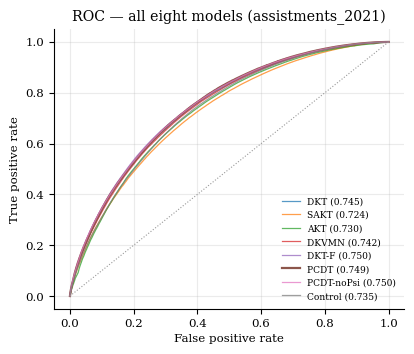

In [16]:
from sklearn.metrics import roc_curve
plt.rcParams.update({"font.family": "serif", "font.size": 8.5, "savefig.dpi": 300,
                     "savefig.bbox": "tight", "axes.spines.top": False, "axes.spines.right": False})

fig, ax = plt.subplots(figsize=(4.2, 3.6))
for k in P.MODEL_ORDER:
    fpr, tpr, _ = roc_curve(Y[M], PRED[k][M])
    ax.plot(fpr, tpr, lw=1.6 if k == "PCDT" else 0.9, alpha=1.0 if k == "PCDT" else .75,
            label=f"{k} ({P.evaluate(PRED[k][M], Y[M])['auc']:.3f})")
ax.plot([0, 1], [0, 1], ":", c="0.6", lw=.8)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title(f"ROC — all eight models ({CFG.dataset})")
ax.legend(fontsize=6.5, frameon=False, loc="lower right"); ax.grid(alpha=.25)
fig.tight_layout(); fig.savefig(os.path.join(DIRS["fig"], "fig_roc_all_models.png"))
fig.savefig(os.path.join(DIRS["fig"], "fig_roc_all_models.pdf")); plt.show()


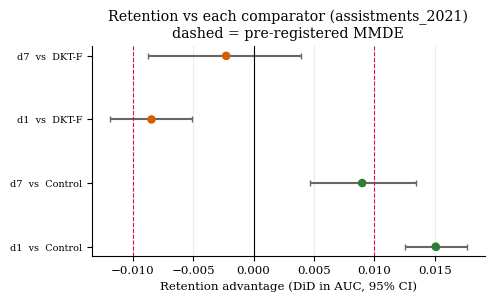

In [17]:
d = T5[T5.adequate] if "adequate" in T5.columns else T5
if len(d):
    fig, ax = plt.subplots(figsize=(5.0, 0.42 * len(d) + 1.4))
    y = np.arange(len(d))
    colour = ["#2E7D32" if c == "Control" else "#D55E00" for c in d["comparator"]]
    # A percentile bootstrap CI is NOT guaranteed to bracket its own point estimate: with a
    # skewed replicate distribution one side can fall the wrong way, which makes an error bar
    # negative and aborts matplotlib. Clip for drawing, but say so loudly — a CI that excludes
    # its own point estimate is diagnostic information, not a cosmetic problem.
    lo_err = (d["retention_advantage"] - d["ci_lo"]).to_numpy(float)
    hi_err = (d["ci_hi"] - d["retention_advantage"]).to_numpy(float)
    bad = (lo_err < 0) | (hi_err < 0)
    if bad.any():
        print(f"*** WARNING: the bootstrap CI does not bracket the point estimate for "
              f"{int(bad.sum())} row(s):")
        print(d.loc[bad, ["horizon", "comparator", "retention_advantage", "ci_lo", "ci_hi"]]
              .round(4).to_string(index=False))
        print("    Error bars are clipped at zero FOR DRAWING ONLY; the tabulated CI is "
              "unchanged. Inspect the replicate distribution before interpreting these rows.")
    ax.errorbar(d["retention_advantage"], y,
                xerr=[np.clip(lo_err, 0, None), np.clip(hi_err, 0, None)],
                fmt="o", ms=4, capsize=2.5, ls="none", ecolor="0.4")
    ax.scatter(d["retention_advantage"], y, c=colour, zorder=3, s=26)
    ax.axvline(0, c="k", lw=.8)
    ax.axvline(CFG.min_meaningful_auc_delta, ls="--", c="crimson", lw=.8)
    ax.axvline(-CFG.min_meaningful_auc_delta, ls="--", c="crimson", lw=.8)
    ax.set_yticks(y); ax.set_yticklabels(d["horizon"] + "  vs  " + d["comparator"], fontsize=7)
    ax.set_xlabel("Retention advantage (DiD in AUC, 95% CI)")
    ax.set_title(f"Retention vs each comparator ({CFG.dataset})\ndashed = pre-registered MMDE")
    ax.grid(axis="x", alpha=.25); fig.tight_layout()
    fig.savefig(os.path.join(DIRS["fig"], "fig_retention.png"))
    fig.savefig(os.path.join(DIRS["fig"], "fig_retention.pdf")); plt.show()
else:
    print("no adequate horizon to plot — nothing is fabricated to fill the figure")


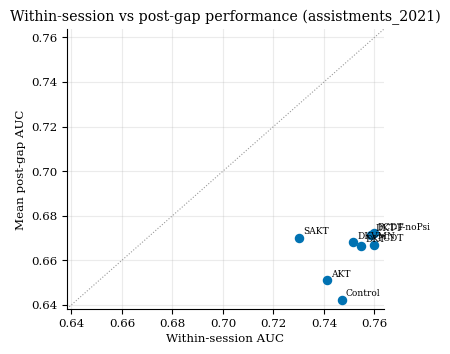

Models below the diagonal degrade across gaps. Ranking divergence needs no exotic mechanism — only that models degrade at DIFFERENT rates.


In [18]:
t = T9.dropna(subset=["auc_mean_postgap"])
if len(t):
    fig, ax = plt.subplots(figsize=(4.4, 3.6))
    ax.scatter(t["auc_within"], t["auc_mean_postgap"], s=34, c="#0072B2", zorder=3)
    for r in t.itertuples():
        ax.annotate(r.model, (r.auc_within, r.auc_mean_postgap), fontsize=6.5,
                    xytext=(3, 3), textcoords="offset points")
    lim = [min(t.auc_within.min(), t.auc_mean_postgap.min()) - .004,
           max(t.auc_within.max(), t.auc_mean_postgap.max()) + .004]
    ax.plot(lim, lim, ":", c="0.6", lw=.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Within-session AUC"); ax.set_ylabel("Mean post-gap AUC")
    ax.set_title(f"Within-session vs post-gap performance ({CFG.dataset})")
    ax.grid(alpha=.25); fig.tight_layout()
    fig.savefig(os.path.join(DIRS["fig"], "fig_within_vs_postgap.png"))
    fig.savefig(os.path.join(DIRS["fig"], "fig_within_vs_postgap.pdf")); plt.show()
    print("Models below the diagonal degrade across gaps. Ranking divergence needs no exotic "
          "mechanism — only that models degrade at DIFFERENT rates.")


## 13. Interpretation — what RQ2 and RQ3 support

Distinguish the four levels deliberately.

**Empirical findings.** Table 2 gives the within-session comparison against the
programmatically identified strongest baseline, judged against the pre-registered MMDE.
Table 5 gives the retention comparison against all three comparators. Table 6 gives the
strict-win counts.

**Interpretation.** Parity with strong tuned baselines is a *result*, not a failure: it says
that on next-interaction prediction the representation neither costs nor buys accuracy, which
is what makes the post-gap comparison interpretable at all. If Ψ beats the session-resetting
control but not models that already encode elapsed time, the defensible claim is that
*modelling time helps* — not that *this operator* is the way to do it.

**Limitations.** No dataset contains a post-test, so nothing here is validated against an
independent educational outcome. Subgroup and fairness analysis is not performed **by design**
(demographics are excluded per the ethics statement), which is a scoping decision, not an
oversight. Effect sizes below the MMDE are reported as differences in *model selection*, not
as claims of superiority.

**Unsupported hypotheses to avoid.** That a rejected dimension is unimportant; that a
statistically significant sub-MMDE difference is educationally meaningful; that a result on
one dataset generalises to the other two. Each is contradicted somewhere in this table set.


## 14. Reproducibility record

In [19]:
CTX.finalize(extra=dict(
    research_question="RQ2+RQ3",
    dataset=CFG.dataset, seed=CFG.seed, seed_index=CFG.seed_index,
    n_learners=int(STATS["n_learners"]) if isinstance(STATS, dict) and "n_learners" in STATS else None,
    strongest_baseline=STRONGEST,
    horizons_real=list(P.REAL_HORIZONS),
    data_paths=CFG.paths))


RUN RQ2RQ3__assistments_2021__seed2 — complete
  runtime        98.12 min
  files written  32
  inputs read    0 (0 missing)
  concurrent     RQ2RQ3__assistments_2021__seed0 (34 files), RQ2RQ3__assistments_2021__seed1 (34 files)
                 ran alongside this one and wrote only into its own folder — expected, not a problem
  isolation      OK — no finished run was modified
  manifest       /home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ2RQ3__assistments_2021__seed2/manifest.json


{'run_id': 'RQ2RQ3__assistments_2021__seed2',
 'description': 'RQ2 + RQ3 — ASSISTments 2020-21, seed 20260204',
 'status': 'complete',
 'notes': '',
 'fixture': False,
 'started': '2026-08-17 20:13:56',
 'finished': '2026-08-17 21:52:04',
 'runtime_minutes': 98.12,
 'output_dir': '/home/hamed/Downloads/Research/P02/PCDT_P2_runs/runs/RQ2RQ3__assistments_2021__seed2',
 'environment': {'python': '3.13.9',
  'platform': 'Linux-7.0.0-28-generic-x86_64-with-glibc2.39',
  'numpy': '2.3.5',
  'pandas': '2.3.3',
  'torch': '2.12.0.dev20260408+cu128',
  'sklearn': '1.7.2',
  'scipy': '1.18.0',
  'matplotlib': '3.10.6',
  'cuda': True,
  'gpu': 'NVIDIA GeForce RTX 5080'},
 'config': {'dataset': 'assistments_2021',
  'root': '/home/hamed/Downloads/Research/dataset',
  'out_root': '/home/hamed/Downloads/Research/P02/PCDT_P2_runs',
  'max_learners': 20000,
  'min_seq_len': 10,
  'max_seq_len': 200,
  'train_frac': 0.5,
  'val_frac': 0.1,
  'test_frac': 0.4,
  'split_mode': 'learner',
  'param_budget